In [3]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

 - 

## variable discriptions
| 欄位 | 描述|
|---|---|
| NAICS | 這些資料為描述美國經濟狀況的統計數據。NAICS 產業分類中的前兩位數用來表示所屬的經濟部門。表 2 彙整了各 2 位數產業部門及其對應的產業說明。|
| franchisecode：| 00000or000010代表沒有frabchise(沒有加盟的意思) |
|newexist: |1=existing business, 2=new business|
|noemp:|number of business employees
|term:|loan term in month
|approvalfy:|fiscal year ofcommitment(SBA 在哪一個「會計年度」核准這筆貸款)
|DateSBAcommitmentissued:|「SBA（美國小企業署）核准／發出貸款承諾的日期」
|UrbanRural:|1=Urban,2=rural,0=undefined
|RevLineCr Revolving line of credit:|Y=Yes,N=No (貸款種類是不是一筆循環貸款)
|lodoc:|y=yes,n=no是不是低文件貸款方案
|ChgOffDate | The date when aloan is declared to be in default
|DisbursementDate | Disbursement date (撥款日期)
|DisbursementGross| Currency Amount disbursed (實際撥款金額)
|BalanceGross Currency | Gross amount outstanding(尚未償還的總貸款金額)
|MIS_Status: | Loan status charged off = CHGOFF,Paid in full =PIF(charged off =呆帳,paid in full=已償還) |
|ChgOffPrinGr |  Charged-offamount👉 實際發生違約後，被銀行認列為損失的金額 |
|grappv | Gross amount of loan approved by bank 銀行核准的貸款總金額（原始貸款額）|
|sba_appv  |SBA’s guaranteed amount of approved loan SBA 對這筆貸款「提供擔保」的金額|

In [40]:
import pandas as pd
df = pd.read_csv(r"D:\桌面\python數據分析實習\重新做一個作品\data\SBAnational.csv")

C:\Users\a0928\AppData\Local\Temp\ipykernel_11672\1442281073.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\桌面\python數據分析實習\重新做一個作品\data\SBAnational.csv")


 - 資料前處理：


In [ ]:
#把$字號拿掉轉成數值型欄位
cn = ['SBA_Appv','GrAppv','ChgOffPrinGr','BalanceGross','DisbursementGross']

for c in cn:
    df[c] = df[c].astype(str).str.replace(r'[$, ]', '', regex=True)
    df[c] = pd.to_numeric(df[c], errors='coerce')
#缺失值處理
#把想了解的y欄位有缺失值的資料刪掉
df = df.dropna(subset=['MIS_Status'])

In [ ]:
#把沒用的欄位刪掉
delete = ['LoanNr_ChkDgt','Name','City','Zip','Bank','ChgOffPrinGr','ChgOffDate'] #把chgoffpringr刪掉，因為它是chgoffprin的衍生欄位，會造成資料洩漏
df = df.drop(columns=delete)

In [7]:
#缺失值處理
#State以n取代缺失值
df['State'] = df['State'].fillna('n')   

In [8]:
#刪除NewExist缺失的資料
df = df.dropna(subset=['NewExist'])

In [9]:
#把RevLine 和LowDoc的缺失值以nan取代
df['RevLineCr'] = df['RevLineCr'].fillna('nan')
df['LowDoc'] = df['LowDoc'].fillna('nan')

In [10]:
#處理日期
# 轉成 Pandas 時間格式後，計算距離某個基準點的天數，刪掉原本的日期
df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'])
df['Days_Since_Appv'] = (df['ApprovalDate'] - df['ApprovalDate'].min()).dt.days
df = df.drop(columns=['ApprovalDate'])

#處理日期
# 轉成 Pandas 時間格式後，計算距離某個基準點的天數，刪掉原本的日期
df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'])
df['Days_Since_Disb'] = (df['DisbursementDate'] - df['DisbursementDate'].min()).dt.days
df = df.drop(columns=['DisbursementDate'])

C:\Users\a0928\AppData\Local\Temp\ipykernel_11672\4014428504.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'])
C:\Users\a0928\AppData\Local\Temp\ipykernel_11672\4014428504.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'])


In [11]:
#把Days_Since_Disb欄位的缺失值以中位數取代
df['Days_Since_Disb'] = df['Days_Since_Disb'].fillna(df['Days_Since_Disb'].median())

 - 開始文字轉數字

In [12]:
#將franchisecode欄位的00000or00001標為0其餘為1
df['FranchiseCode_Binary'] = df['FranchiseCode'].apply(lambda x: 0 if x in [0, 1] else 1)
df = df.drop(columns=['FranchiseCode'])

In [13]:
# import missingno as msno
# import matplotlib.pyplot as plt

# # 挑選你想檢查的兩個欄位（bank,bankstate）
# cols = ['BankState']
# msno.heatmap(df[cols])
# plt.show()
# #發現重合程度超高，於是想建立子資料及觀察更多欄位
# # 抓出 Bank 欄位缺失的所有資料

# # 看看這個子資料集的大小
# print(f"缺失資料筆數: {df_missing.shape[0]}")


In [14]:
#df_specific_missing = df[(df['Bank'] == 'Missing_Data') & (df['BankState'] == 'MD')].copy()

# 查看結果
#print(f"符合條件的筆數: {df_specific_missing.shape[0]}")
#print(df_specific_missing.head())

#查看資料發現MISSING的借貸資料(GrAppv)都偏低，相較於整體資料的偏態跟紐曲都較小，代表他們的借貸行為較為穩定，違約率也較低

#原始資料做特徵工程建立一個欄位，告訴AI這些資料的人比較乖
#df['Is_Missing_Group'] = (df['Bank'] == 'Missing_Data').astype(int)

In [ ]:
#處理NAICS的資料，依據他的前兩個數字做分類
df['NAICS_Section'] = df['NAICS'].astype(str).str[:2]

# 處理無效的 NAICS (例如原始資料可能是 0，轉字串後變 '0')
# 將其標記為 'Unknown' 或一個特定的類別
df['NAICS_Section'] = df['NAICS_Section'].replace(['0', '00', 'na', 'n'], 'Unknown')

In [16]:
#刪除NAICS欄位
df = df.drop(columns=['NAICS'])

In [17]:
#切X Y
X = df.drop(columns=['MIS_Status'])
y = df['MIS_Status']

In [18]:
#切訓練 測試
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"訓練集大小: {X_train.shape[0]}，測試集大小: {X_test.shape[0]}")

訓練集大小: 717626，測試集大小: 179407


In [20]:
y_train = y_train.apply(lambda x: 1 if x == 'CHGOFF' else 0)
y_test = y_test.apply(lambda x: 1 if x == 'CHGOFF' else 0)

In [ ]:
import category_encoders as ce

# 1. 初始化 Target Encoder，指定你要轉換的四個欄位
# cols 參數傳入一個列表，包含 'State' 'BankState' 'NAICS_Section' 和 'ApprovalFY'
target_enc = ce.TargetEncoder(cols=['State', 'BankState','NAICS_Section','ApprovalFY'])

# 2. 擬合 (Fit)：讓編碼器從訓練集中學習這四個欄位與違約 (y_train) 的關係
# 它會建立「違約率對照表」
target_enc.fit(X_train, y_train)

# 3. 轉換 (Transform)：將對照表的數值填入訓練集與測試集
# 這裡就是你說的「對應」：測試集的州名會對應到訓練集算出的違約率
X_train = target_enc.transform(X_train)
X_test = target_enc.transform(X_test)

In [22]:
#覺得借貸金額極端值太嚴重，最大值和最小值超過2個數量級，可能需要先做標準化或取對數等行為以幫助接下來機器學習
colstolog = ['BalanceGross','SBA_Appv','GrAppv','DisbursementGross']

#對這些欄位取對數
X_train[colstolog] = X_train[colstolog].apply(np.log1p)
X_test[colstolog] = X_test[colstolog].apply(np.log1p)
print(X_train.head())

           State  BankState  ApprovalFY  Term  NoEmp  NewExist  CreateJob  \
496943  0.176101   0.076495    0.021356   180      2       2.0          0   
340596  0.273812   0.252169    0.410129    65      2       1.0          6   
645061  0.195431   0.220572    0.145961   300      4       1.0          6   
300395  0.185548   0.220572    0.410129    68      2       1.0          0   
599832  0.176602   0.095832    0.018435    60      1       1.0          0   

        RetainedJob  UrbanRural RevLineCr LowDoc  DisbursementGross  \
496943            0           0         N      N          12.724869   
340596            6           1         0      N          13.849913   
645061            4           1         0      N          12.672950   
300395            2           1         N      N          10.463132   
599832            0           0         N      N           9.798183   

        BalanceGross     GrAppv   SBA_Appv  Days_Since_Appv  Days_Since_Disb  \
496943           0.0  12.79386

In [ ]:
#發現newexist為0的資料其超過90%為循環貸款，跟普遍的不同 考慮做研究
#g = df[df['NewExist']==0]

bank 缺1500
bankstate 缺1600 上面兩種有關係

chgoffdate缺失值達82%--刪掉
mis_state的缺失值資料直接刪除

NewExist資料應該只有種類1,2但還有0、空值，把後面兩種刪掉
revlinecr遺漏4500
lowdoc遺漏2500
disbursementdate缺2300考慮刪除

In [23]:
#資料前處理-one-hot encoding
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False,drop='first') # drop='first' 可以避免虛擬變數陷阱
encoded_data = enc.fit_transform(X_train[['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']])

encoded_df = pd.DataFrame(
    encoded_data, 
    columns=enc.get_feature_names_out(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']),
    index=X_train.index # 關鍵：確保索引一致，合併才不會錯位
)

# --- 新增：合併回原始 DataFrame 並移除舊欄位 ---
# 這樣你的 df_final 就會包含「對數轉換後的金額」+「One-Hot 欄位」
X_train_final = pd.concat([X_train.drop(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc'], axis=1), encoded_df], axis=1)

print(X_train_final.head())



           State  BankState  ApprovalFY  Term  NoEmp  CreateJob  RetainedJob  \
496943  0.176101   0.076495    0.021356   180      2          0            0   
340596  0.273812   0.252169    0.410129    65      2          6            6   
645061  0.195431   0.220572    0.145961   300      4          6            4   
300395  0.185548   0.220572    0.410129    68      2          0            2   
599832  0.176602   0.095832    0.018435    60      1          0            0   

        DisbursementGross  BalanceGross     GrAppv  ...  RevLineCr_`  \
496943          12.724869           0.0  12.793862  ...          0.0   
340596          13.849913           0.0  13.849913  ...          0.0   
645061          12.672950           0.0  12.672950  ...          0.0   
300395          10.463132           0.0  10.463132  ...          0.0   
599832           9.798183           0.0   9.798183  ...          0.0   

        RevLineCr_nan  FranchiseCode_Binary_1  LowDoc_A  LowDoc_C  LowDoc_N  \
496943 

In [24]:
#X_test也做一樣的處理
encoded_data_test = enc.transform(X_test[['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']])
encoded_df_test = pd.DataFrame(
    encoded_data_test,
    columns=enc.get_feature_names_out(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc']),
    index=X_test.index
)
X_test_final = pd.concat([X_test.drop(['NewExist', 'UrbanRural', 'RevLineCr','FranchiseCode_Binary','LowDoc'], axis=1), encoded_df_test], axis=1)
print(X_test_final.head())

           State  BankState  ApprovalFY  Term  NoEmp  CreateJob  RetainedJob  \
553235  0.185548   0.220572    0.018435   300     55          0            0   
485034  0.158153   0.101437    0.021356    60      6          0            0   
871634  0.129306   0.066326    0.042448    60     10          0            0   
838491  0.176961   0.064170    0.042448    84      1          0            0   
47584   0.223748   0.157888    0.275215   240      3          3            3   

        DisbursementGross  BalanceGross     GrAppv  ...  RevLineCr_`  \
553235          13.681980           0.0  13.681980  ...          0.0   
485034          10.308986           0.0  10.308986  ...          0.0   
871634          10.463132           0.0  10.463132  ...          0.0   
838491           9.903538           0.0   9.903538  ...          0.0   
47584           13.081543           0.0  13.081543  ...          0.0   

        RevLineCr_nan  FranchiseCode_Binary_1  LowDoc_A  LowDoc_C  LowDoc_N  \
553235 

d:\桌面\python數據分析實習\重新做一個作品\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [25]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# #選擇要標準化的欄位
# num_cols = ['State','BankState','ApprovalFY','Term','NoEmp','CreateJob','RetainedJob','DisbursementGross','BalanceGross','GrAppv', 'SBA_Appv','Days_Since_Appv'
#             ,'Days_Since_Disb','NAICS_Section' ]

In [26]:
#改成動態抓取數值型欄位，這樣以後如果有新增數值型欄位就不會忘記標準化了
num_cols = X_train_final.select_dtypes(include="number").columns.tolist()

In [27]:
# 1. 初始化標準化器
scaler = StandardScaler()

# 2. 建立副本，避免改動到原始切分好的資料
X_train_scaled = X_train_final.copy()
X_test_scaled = X_test_final.copy()

# 3. 關鍵步驟：只對「訓練集」進行 Fit（學習平均值與標準差）
# 然後同時對「訓練集」與「測試集」進行 Transform
X_train_scaled[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_final[num_cols])

# 檢查結果：平均值應接近 0，標準差應接近 1
print("訓練集平均值:\n", X_train_scaled[num_cols].mean().round(2))
print("訓練集標準差:\n", X_train_scaled[num_cols].std().round(2))

訓練集平均值:
 State                    -0.0
BankState                -0.0
ApprovalFY               -0.0
Term                      0.0
NoEmp                    -0.0
CreateJob                -0.0
RetainedJob               0.0
DisbursementGross        -0.0
BalanceGross             -0.0
GrAppv                    0.0
SBA_Appv                  0.0
Days_Since_Appv          -0.0
Days_Since_Disb          -0.0
NAICS_Section             0.0
NewExist_1.0              0.0
NewExist_2.0              0.0
UrbanRural_1             -0.0
UrbanRural_2              0.0
RevLineCr_-               0.0
RevLineCr_.               0.0
RevLineCr_0              -0.0
RevLineCr_1               0.0
RevLineCr_2              -0.0
RevLineCr_3               0.0
RevLineCr_7               0.0
RevLineCr_A               0.0
RevLineCr_C              -0.0
RevLineCr_N              -0.0
RevLineCr_R               0.0
RevLineCr_T              -0.0
RevLineCr_Y               0.0
RevLineCr_`              -0.0
RevLineCr_nan             0.0
F

In [28]:
from sklearn.linear_model import ElasticNetCV

In [29]:
en_cv = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
    cv=5, 
    random_state=42, 
    max_iter=5000  # 增加迭代次數確保收斂
)

In [30]:
en_cv.fit(X_train_scaled, y_train)

ElasticNetCV(cv=5, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1], max_iter=5000,
             random_state=42)

In [31]:
# 1. 找出係數不為 0 的特徵名稱
selected_features = X_train_scaled.columns[en_cv.coef_ != 0].tolist()

print(f"原始特徵數量: {X_train_scaled.shape[1]}")
print(f"篩選後特徵數量: {len(selected_features)}")
print("被選中的特徵:", selected_features)

# 2. 重新定義訓練集與測試集，只保留這些精華特徵
X_train_reduced = X_train_scaled[selected_features]
X_test_reduced = X_test_scaled[selected_features]

原始特徵數量: 41
篩選後特徵數量: 35
被選中的特徵: ['State', 'BankState', 'ApprovalFY', 'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv', 'Days_Since_Appv', 'Days_Since_Disb', 'NAICS_Section', 'NewExist_1.0', 'UrbanRural_1', 'UrbanRural_2', 'RevLineCr_.', 'RevLineCr_2', 'RevLineCr_3', 'RevLineCr_7', 'RevLineCr_C', 'RevLineCr_N', 'RevLineCr_R', 'RevLineCr_T', 'RevLineCr_Y', 'RevLineCr_`', 'RevLineCr_nan', 'FranchiseCode_Binary_1', 'LowDoc_A', 'LowDoc_C', 'LowDoc_N', 'LowDoc_S', 'LowDoc_Y', 'LowDoc_nan']


 - 開套模型咯

In [32]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

In [33]:
## 方案 A：使用 Random Forest訓練
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_reduced, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [34]:
#套入模型
y_pred = rf_model.predict(X_test_reduced)
y_test_proba = rf_model.predict_proba(X_test_reduced)[:, 1]

In [ ]:
#  ## 方案 B：使用 XGBoost 訓練
# xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
# xgb_model.fit(X_train_reduced, y_train) 

d:\桌面\python數據分析實習\重新做一個作品\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:37:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

 - 可加上grid research找到最好的模型

In [ ]:
# #訓練套入模型
# y_train_pred= xgb_model.predict(X_train_reduced)
# y_train_proba = xgb_model.predict_proba(X_train_reduced)[:, 1]

In [ ]:
# #測試套入模型
# y_test_pred = xgb_model.predict(X_test_reduced)
# y_test_proba = xgb_model.predict_proba(X_test_reduced)[:, 1]

In [ ]:
# 方案 B：使用 gridsearch (如果資料很大，通常比 RF 更準)
#1. 初始化模型，先用預設參數訓練看看表現
#xgb_model = XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=42)


# 2. 設定想要測試的參數網格 (Grid)
# 建議針對關鍵參數進行測試，避免跑太久
#param_grid = {
#    'n_estimators': [100, 200],           # 樹的棵數
#    'max_depth': [3, 6, 9],               # 樹的深度 (3-10 是常見區間)
#    'learning_rate': [0.01, 0.1, 0.2],    # 學習率 (步長)
#    'subsample': [0.8, 1.0]               # 每次訓練取用的資料比例
#}

# 3. 初始化 GridSearchCV
# cv=3 代表做三折交叉驗證；n_jobs=-1 代表使用電腦所有核心加速跑
#grid_xgb = GridSearchCV(
#    estimator=xgb_model,
#    param_grid=param_grid,
#    cv=3, 
#    scoring='f1',       # 因為是分類問題，用 F1 或 ROC-AUC 比較專業
#    n_jobs=-1,
#    verbose=2           # 讓你看到跑的進度
#)

#4
#grid_xgb.fit(X_train_reduced, y_train)

# 5. 輸出結果
#print(f"最佳參數組合: {grid_xgb.best_params_}")
#print(f"最佳 F1 分數: {grid_xgb.best_score_:.4f}")  
# 6. 取得最強模型來做最後的預測
#final_xgb = grid_xgb.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits


KeyboardInterrupt: 

In [35]:
#結果分析(一)查看分類報告
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97    147898
           1       0.89      0.77      0.83     31509

    accuracy                           0.94    179407
   macro avg       0.92      0.87      0.90    179407
weighted avg       0.94      0.94      0.94    179407



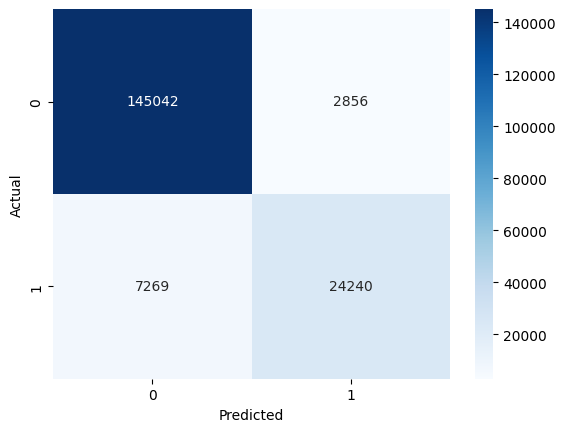

In [37]:
#結果分析(二)混淆矩陣
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:
#結果分析(三)查看AUC分數
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_test_proba) # 記得用機率值而不是 0/1 類別
print(f"AUC Score: {auc}")

AUC Score: 0.9678583128443569


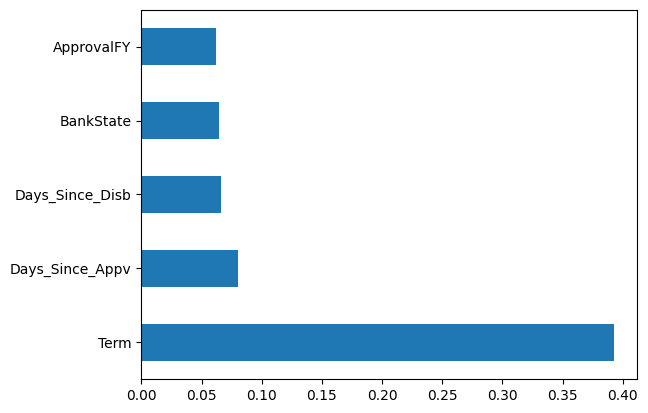

In [39]:
import matplotlib.pyplot as plt
feat_importances = pd.Series(rf_model.feature_importances_, index=X_test_reduced.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

In [ ]:
# #儲存完成的模型
# # 假設你的模型變數名稱是 final_xgb_model
# xgb_model.save_model("model/sba_xgboost_model.json")

# print("XGBoost 模型已成功儲存為 JSON 格式！")

XGBoost 模型已成功儲存為 JSON 格式！


 - 準備 power bi 資料的程式碼

In [ ]:
power_bi_df = X_test_reduced.copy()

# 1. 補回原始金額 (從原始 df 找回，不要用對數後的)
power_bi_df['Original_Amount'] = df.loc[X_test_reduced.index, 'GrAppv']

# 2. 加入預測結果
power_bi_df['Default_Probability'] = y_test_proba 
power_bi_df['Actual_Status'] = y_test

# 3. 匯出
power_bi_df.to_csv("reports/power_bi_data.csv", index=False)